In [11]:
import numpy as np 
import pandas as pd 
from glob import glob
from tqdm import tqdm
from pybedtools import BedTool
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.gridspec as gridspec
from datasketch import MinHash
import edlib
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu
import gzip 
import re
import warnings
warnings.filterwarnings("ignore")
from matplotlib.patches import Rectangle
import edlib
from matplotlib.collections import BrokenBarHCollection
import os
import networkx as nx
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage
from matplotlib import cm, colors


In [2]:
    
canonical_arms = [
    f"chr{i}{arm}" for i in range(1, 23) for arm in ("p", "q")
] + ["chrXp", "chrXq"]
        

In [6]:

dtype_map = {
    "assignment": "category",
    "contig_i": "string",
    "contig_j": "string",
    "label_i": "string",
    "label_j": "string",
}

similarity_df = pd.read_csv(
    "data_for_submission/pairwise_all_arms.csv.gz",
    compression="gzip",
    dtype=dtype_map,
    low_memory=False,
)

sim_cols = [c for c in similarity_df.columns if c.startswith("sim_t")]
similarity_df[sim_cols] = similarity_df[sim_cols].astype("float32")


In [7]:

vals = []

for column in range(50,4050,50):
    vals.append(similarity_df[f'sim_t{str(column)}'].to_numpy())
    

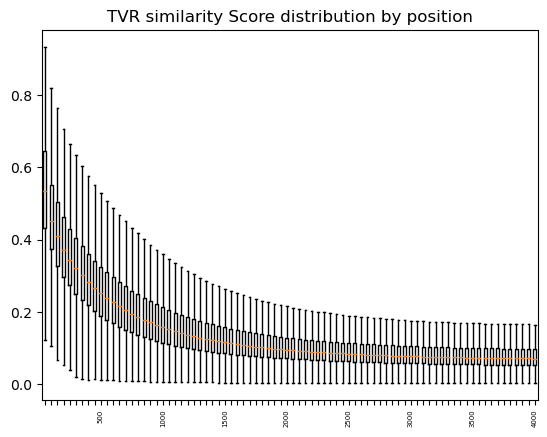

In [8]:
# FIG 2B

plt.boxplot(vals, sym="")

bp_bins = range(50, 4050, 50)

positions = range(1, len(bp_bins) + 1)

labels = [str(bp) if bp % 500 == 0 else "" for bp in bp_bins]

plt.xticks(ticks=positions, labels=labels,rotation=90,fontsize=5)
plt.title('TVR similarity Score distribution by position')
plt.show()

##### For Figure 2C - same code used for plotting fig 1D, just zoomed in on first 500bp. if you'd like to recreate that, please go check out Fig1 notebook

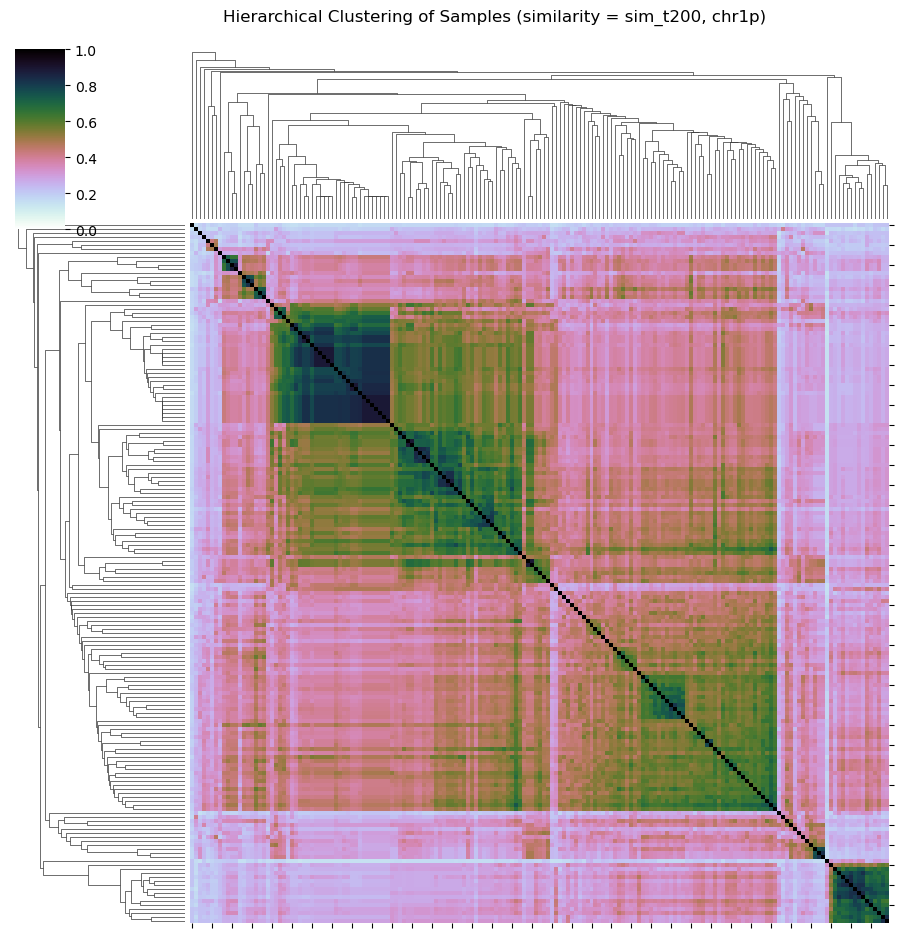

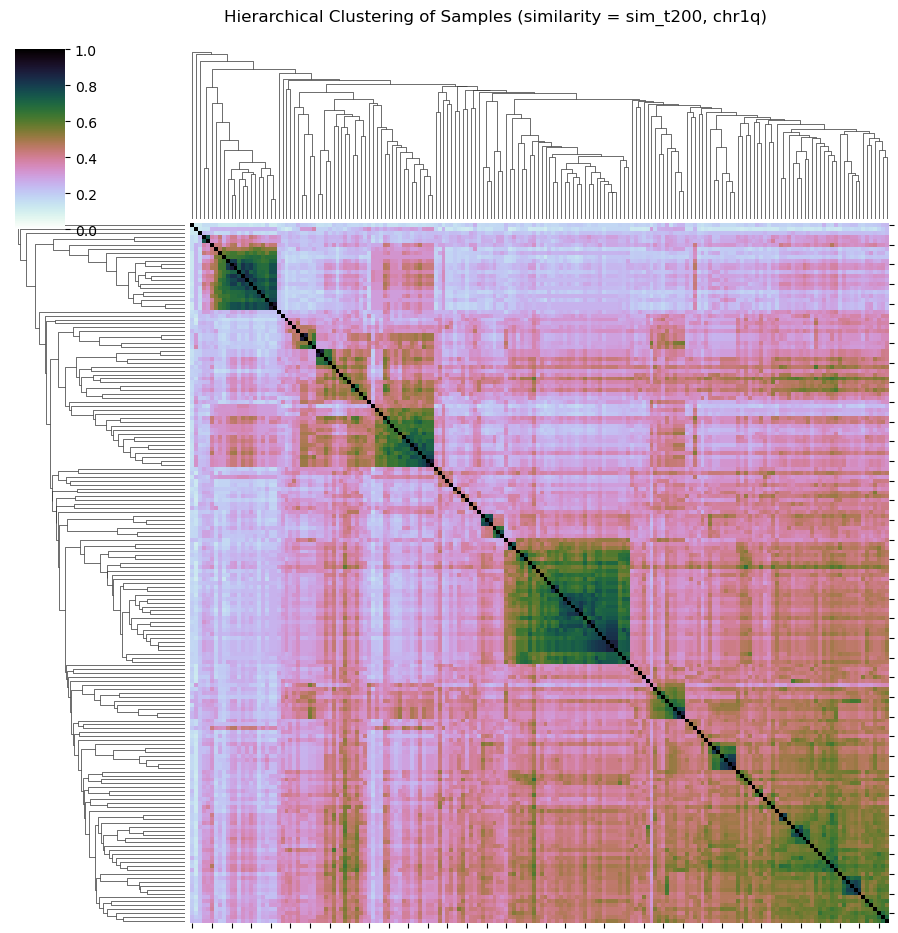

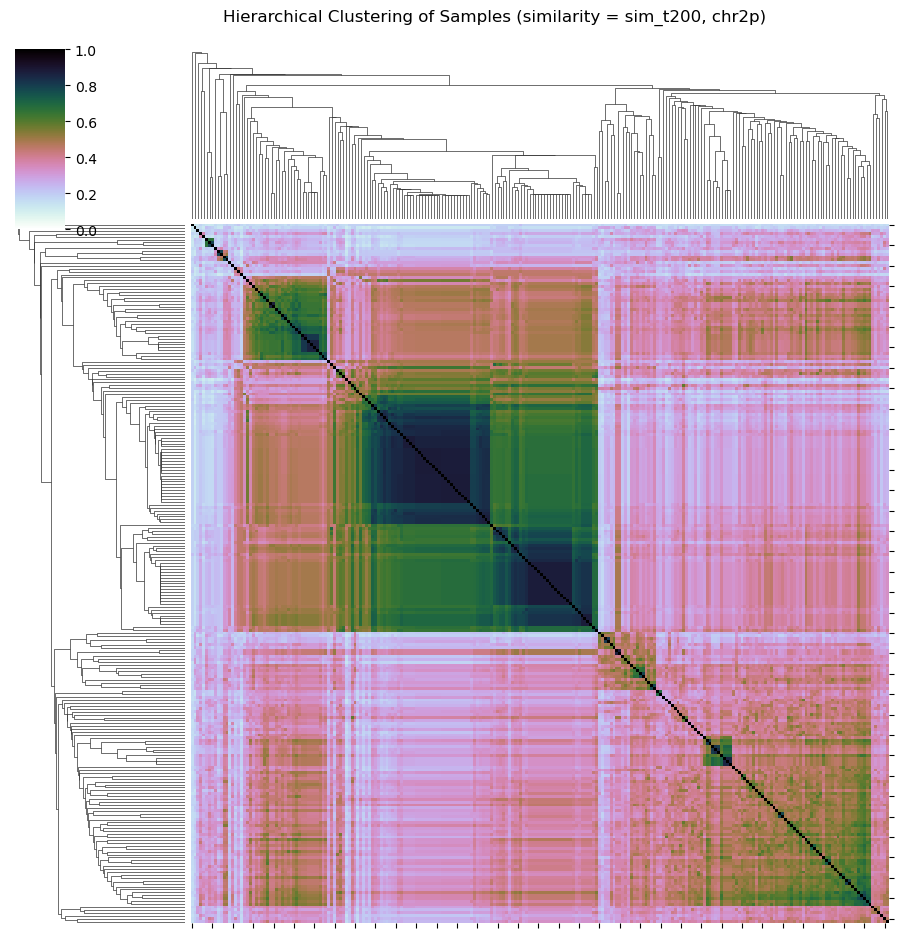

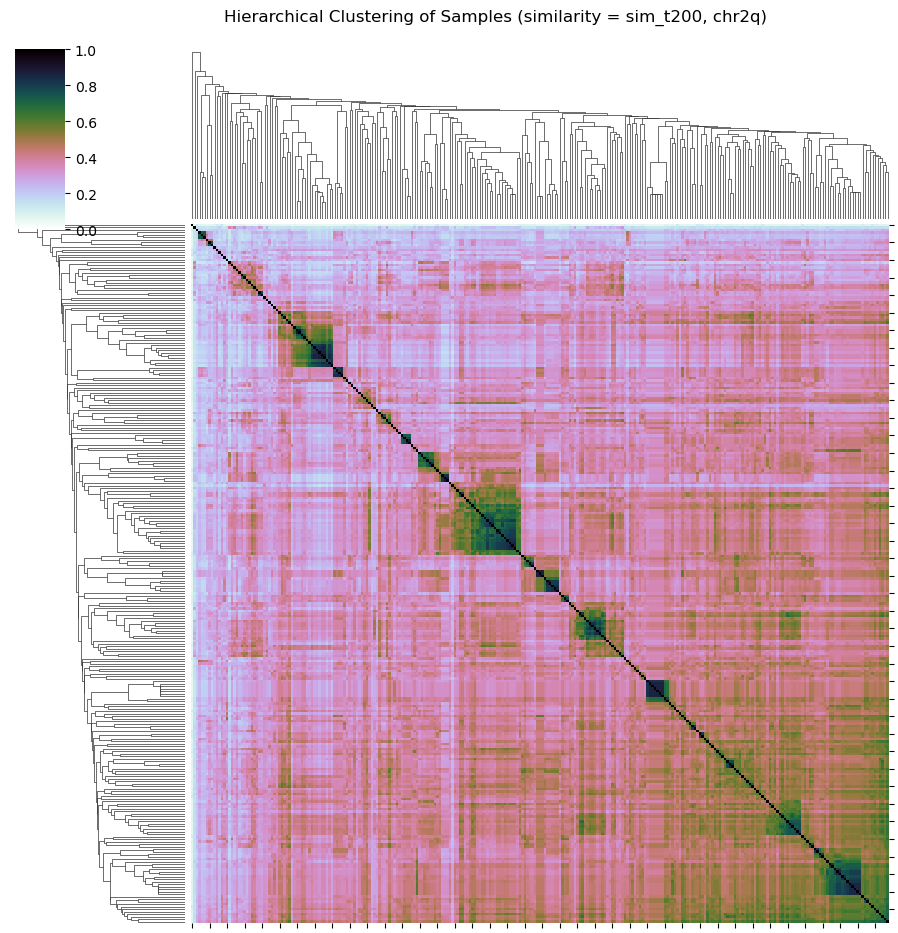

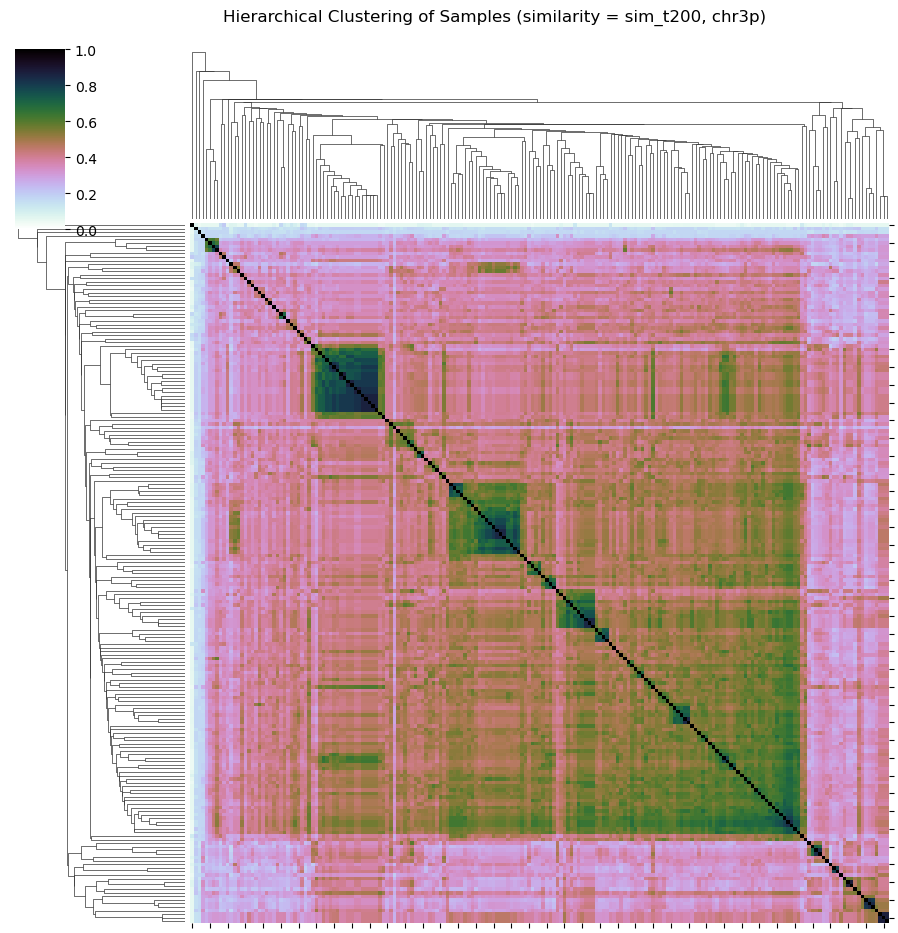


KeyboardInterrupt



In [9]:
# Fig 2D

sim_col = "sim_t200"   # <-- change this to whichever you want


for chrom in canonical_arms:

    df=similarity_df[similarity_df.assignment==chrom] 
    labels = np.unique(df[["label_i", "label_j"]].values.ravel())
    labels = list(labels)   # for ordering
    N = len(labels)

    M = pd.DataFrame(np.nan, index=labels, columns=labels, dtype=float)

    for _, row in df.iterrows():
        i, j = row["label_i"], row["label_j"]
        sim = row[sim_col]
        M.loc[i, j] = sim
        M.loc[j, i] = sim

    # similarity with itself = 1
    np.fill_diagonal(M.values, 1.0)

    # distance = 1 - similarity
    D = 1 - M

    # clustermap uses condensed distance form
    D_condensed = squareform(D.values, checks=False)

    linkage_matrix = linkage(D_condensed, method="average")

#     sns.set_theme(context="notebook", style="white")

    g = sns.clustermap(
        M,
        row_linkage=linkage_matrix,
        col_linkage=linkage_matrix,
        cmap="cubehelix_r",
        vmin=0,
        vmax=1,
        linewidths=0,
        figsize=(10, 10),

    )
    g.ax_heatmap.set_yticklabels([])
    g.ax_heatmap.set_xticklabels([])



    plt.suptitle(f"Hierarchical Clustering of Samples (similarity = {sim_col}, {chrom})", y=1.02)
#     plt.savefig(f"tvr_heatmap_dendogram/{chrom}_{sim_col}_heatmap_with_denogram.pdf",dpi=350)
    plt.show()
    
    

     assignment  target_bp  cutoff  pct_with_partner  n_hit  n_total
2760        ALL        200    0.05        100.000000   9489     9489
2761        ALL        200    0.10         99.957846   9485     9489
2762        ALL        200    0.15         99.915692   9481     9489
2763        ALL        200    0.20         99.831384   9473     9489
2764        ALL        200    0.25         99.473074   9439     9489
2765        ALL        200    0.30         98.988302   9393     9489
2766        ALL        200    0.35         98.419222   9339     9489
2767        ALL        200    0.40         97.302139   9233     9489
2768        ALL        200    0.45         95.141743   9028     9489
2769        ALL        200    0.50         91.105491   8645     9489
2770        ALL        200    0.55         85.045843   8070     9489
2771        ALL        200    0.60         76.899568   7297     9489
2772        ALL        200    0.65         65.591738   6224     9489
2773        ALL        200    0.70

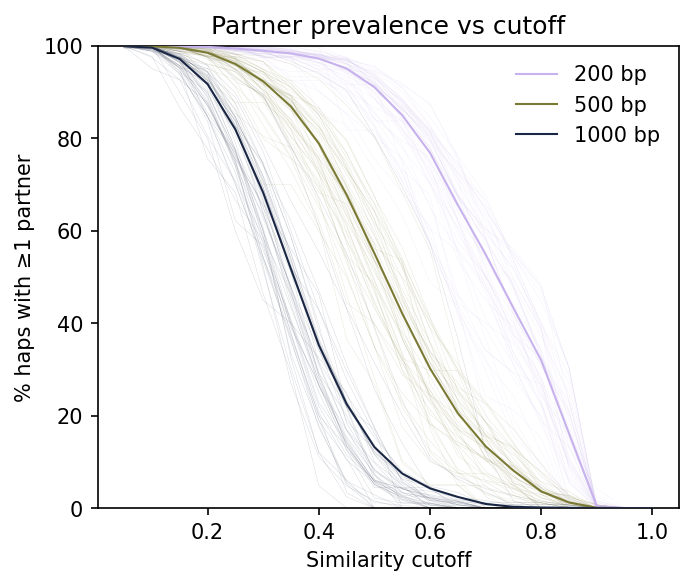

In [12]:
# Fig 2E

from matplotlib import cm, colors

def pick_sim_cols(df, targets=(200, 500, 1000), prefix="sim_t"):
    sim_cols = [c for c in df.columns if c.startswith(prefix)]
    coords = np.array([int(re.findall(rf"{prefix}(\d+)", c)[0]) for c in sim_cols])
    out = {}
    for t in targets:
        j = int(np.argmin(np.abs(coords - t)))
        out[t] = sim_cols[j]
    return out

target_to_col = pick_sim_cols(similarity_df, targets=(200, 500, 1000))


rows = []
for target_bp, col in target_to_col.items():
    tmp = similarity_df[["assignment", "label_i", "label_j", col]].copy()
    tmp = tmp.rename(columns={col: "similarity"})
    tmp["target_bp"] = target_bp
    tmp["actual_bp"] = int(re.findall(r"sim_t(\d+)", col)[0])
    rows.append(tmp)

long = pd.concat(rows, ignore_index=True).dropna(subset=["similarity"])
long.head()


def percent_with_partner(df, cutoff):
    """
    df must have columns: assignment, label_i, label_j, similarity
    Hap identity is (assignment, label).

    Returns:
      pct_with_partner, n_haps_with_partner, n_total_haps
    """
    # chrom-specific hap IDs
    hap_i = df["assignment"].astype(str) + "_" + df["label_i"].astype(str)
    hap_j = df["assignment"].astype(str) + "_" + df["label_j"].astype(str)

    all_haps = pd.unique(pd.concat([hap_i, hap_j], ignore_index=True))
    n_total = len(all_haps)

    hits = df.loc[df.similarity >= cutoff]
    if hits.empty:
        return 0.0, 0, n_total

    hit_haps = pd.unique(pd.concat([
        hits["assignment"].astype(str) + "_" + hits["label_i"].astype(str),
        hits["assignment"].astype(str) + "_" + hits["label_j"].astype(str)
    ], ignore_index=True))

    n_hit = len(hit_haps)
    pct = 100.0 * n_hit / n_total if n_total else 0.0
    return pct, n_hit, n_total

cutoffs = np.linspace(0.05, 1, 20)

rows = []

for (chrom, bp), g in long.groupby(["assignment", "target_bp"]):
    for c in cutoffs:
        pct,n_hit,n_total = percent_with_partner(g, c)

        rows.append({
            "assignment": chrom,
            "target_bp": bp,
            "cutoff": c,
            "pct_with_partner": pct,
            "n_hit": n_hit,
            "n_total": n_total
        })

pct_chrom = pd.DataFrame(rows)


rows = []

for bp, g in long.groupby("target_bp"):
    for c in cutoffs:
        pct,n_hit,n_total = percent_with_partner(g, c)
        rows.append({
            "assignment": "ALL",
            "target_bp": bp,
            "cutoff": c,
            "pct_with_partner": pct,
            "n_hit": n_hit,
            "n_total": n_total
        })

pct_all = pd.DataFrame(rows)

pct = pd.concat([pct_chrom, pct_all], ignore_index=True)



bps = [200, 500, 1000]

cmap = cm.get_cmap("cubehelix_r")
bp_colors = dict(zip(bps, cmap(np.linspace(0.25, 0.85, len(bps)))))

plt.figure(figsize=(5, 4), dpi=150)

for bp in bps:
    sub = pct[pct.target_bp == bp]
    chroms = sorted(c for c in sub.assignment.unique() if c != "ALL")

    for chrom in chroms:
        tmp = sub[sub.assignment == chrom]
#         print(tmp)
        plt.plot(
            tmp.cutoff,
            tmp.pct_with_partner,
            color=bp_colors[bp],
            lw=0.2,
            alpha=0.2,
            zorder=1
        )

    tmp = sub[sub.assignment == "ALL"]
    plt.plot(
        tmp.cutoff,
        tmp.pct_with_partner,
        color=bp_colors[bp],
        lw=1,
        label=f"{bp} bp",
        zorder=3
    )


    print(tmp)
    
plt.xlabel("Similarity cutoff")
plt.ylabel("% haps with ≥1 partner")
plt.title("Partner prevalence vs cutoff")
plt.ylim(0, 100)
plt.legend(frameon=False)
# plt.tight_layout()
# plt.savefig('pb_partner_prevalence_v_cutoff.pdf',dpi=300)
plt.show()

### PCLAI based analysis below

In [4]:

chm13_telos = pd.read_csv('data_for_submission/chm13/chm13v2.0_telomere.noY.terminal_only.bed',sep="\t",
                          header=None,names=['chrom','start','end'])

chm13_chrom_assignment = []

for _,row in chm13_telos.iterrows():
    
    if row.start == 0:
        
        chm13_chrom_assignment.append(f'{row.chrom}p')
    else:
        chm13_chrom_assignment.append(f'{row.chrom}q')
    
chm13_telos['assignment'] = chm13_chrom_assignment


def read_pclai(bed):
    
    header = ['chrom','start','end','name','confidence']

    df = pd.read_csv(
    bed, 
    sep="\t", 
    usecols=range(5),  
    names=header
    )
    
    pattern = r'^(?P<id>[^/]+)/(?P<hap>[^/]+)/.*_\((?P<PC1>[^,]+),(?P<PC2>[^)]+)\)$'

    new_cols = df['name'].str.extract(pattern)

    df = pd.concat([df, new_cols], axis=1)
    
    return df 
labels = np.union1d(similarity_df.label_i, similarity_df.label_j)

labels_list = list(labels)

pclai_dict = {}

num_not_work = 0
for l in labels_list:
    
    file_name = f'data_for_submission/pclai-in-terminal-subtelo/{l}.pclai.terminal.bed'

    
    try: 
        df = read_pclai(file_name)

        key = f'{df.id.iloc[0]}_{df.hap.iloc[0][-1]}'
        
        pclai_dict[key] = df
    except:
        num_not_work+=1
        
        
print(f'Number of indiviudals without PCLAI : {num_not_work}')
    
    

Number of indiviudals without PCLAI : 2


In [14]:
def get_window_distances(df1, df2):

    merged = pd.merge(df1, df2, on=['chrom', 'start', 'end'], suffixes=('_1', '_2'))

    distances = np.hypot(
        merged['PC1_1'].astype(float) - merged['PC1_2'].astype(float), 
        merged['PC2_1'].astype(float) - merged['PC2_2'].astype(float)
    )
    
    return merged['start'].values, merged['end'].values, distances.values


def get_pclai_from_telo_alignment(row,pclai_dict,chm13_telos):
    
    # first we need to get the values for tvr alignment
    
    chrom_end = row.assignment
    tvr_alignment_score = row.sim_t200 
    
    label_i = row.label_i
    
    label_j = row.label_j

    
    
    telo_match = chm13_telos[chm13_telos.assignment == chrom_end]

    label_i_df = pclai_dict[label_i]
    label_j_df = pclai_dict[label_j]

    chm13_chrom = telo_match.chrom.iloc[0]
    
    if 'p' in chrom_end:
        chm13_start = telo_match.end.iloc[0]

        chm13_end = telo_match.end.iloc[0] + 1_000_000 

    elif 'q' in chrom_end:
        chm13_start = telo_match.start.iloc[0] - 1_000_000
        chm13_end = telo_match.start.iloc[0]
    
    
    
    
    tmp_df = label_i_df[label_i_df.chrom == chm13_chrom]
                    
    label_i_tmp_df = tmp_df[(tmp_df.start >= chm13_start) & (tmp_df.end <= chm13_end)]
        
    tmp_df = label_j_df[label_j_df.chrom == chm13_chrom]
        
    label_j_tmp_df = tmp_df[(tmp_df.start >= chm13_start) & (tmp_df.end <= chm13_end)]       
        
    
    if len(label_i_tmp_df) < 1 or len(label_j_tmp_df) < 1:
        return None
    else:
        
        merged = get_window_distances(label_j_tmp_df,label_i_tmp_df)
                
        output = [chrom_end,label_i,label_j,tvr_alignment_score,merged]
        
        return output
        
pairwise_comparisons_measured = 0
pairwise_comparisons_missed = 0

all_output = []
for row in tqdm(similarity_df.itertuples()):    

    if row.label_i not in pclai_dict:
        continue
    if row.label_j not in pclai_dict:
        continue
    
    
#     try:
    output = get_pclai_from_telo_alignment(row,pclai_dict,chm13_telos)
    all_output.append(output)
    pairwise_comparisons_measured+=1
  
    
low,high = np.percentile([e[-2] for e in all_output if type(e) != type(None)],[1,99])



highly_related =[]
not_related = []

represented_chroms = []

for entry in all_output:
    
    if type(entry)== type(None):
        continue
    
    if float(entry[-2]) > 0.85:
        
        
        start,stop,values = entry[-1]
        highly_related.append(np.nanmean(values))
        
    elif float(entry[-2]) < 0.15:
        
        start,stop,values = entry[-1]
        if len(values) > 0:
                
            not_related.append(np.nanmean(values))
    
    else:
        continue



1203843it [24:02:48, 13.91it/s]  


Not related crosses 0.5 at: 2.2703843710184035
Highly related crosses 0.5 at: 0.44173712787091607


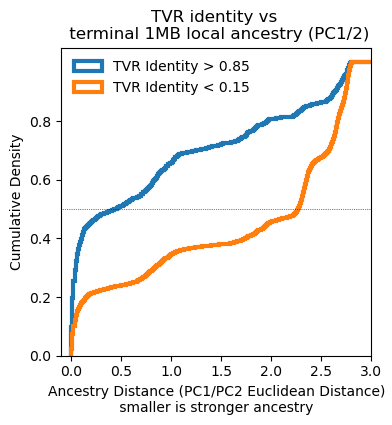

In [16]:
sns.reset_orig()
nr_median = np.nanpercentile(not_related, 50)
hr_median = np.nanpercentile(highly_related, 50)

print("Not related crosses 0.5 at:", nr_median)
print("Highly related crosses 0.5 at:", hr_median)
plt.figure(figsize=(4,4))
    
# plt.boxplot([not_related,highly_related])
plt.hist(highly_related,histtype='step',bins=300,range=(0,3.1),
         density=True,cumulative=True,label='TVR Identity > 0.85',lw=3)
plt.hist(not_related,histtype='step',bins=300,range=(0,3.1),
         density=True,cumulative=True,label='TVR Identity < 0.15',lw=3)
plt.legend(frameon=False)
plt.xlim(-.1,3)
plt.title('TVR identity vs \n terminal 1MB local ancestry (PC1/2)')
plt.xlabel('Ancestry Distance (PC1/PC2 Euclidean Distance)\n smaller is stronger ancestry ')
plt.ylabel('Cumulative Density')
plt.yticks(np.arange(0,1,0.2))
plt.axhline(0.5,lw=0.5,ls='dotted',c='black')
# plt.savefig('TVR_identity_vs_pclai.pdf',dpi=300)
plt.show()

In [48]:
from scipy.stats import mannwhitneyu 


hr_arr = np.array(highly_related)
nr_arr = np.array(not_related)

highly_related_clean = hr_arr[np.isfinite(hr_arr)]
not_related_clean = nr_arr[np.isfinite(nr_arr)]

stat, p_value = mannwhitneyu(highly_related_clean, not_related_clean)


print(len(highly_related_clean),len(not_related_clean))

print(stat,p_value)

3201 15654
15042047.0 7.74817515985339e-279


In [49]:
SCORE_COLS = ("sim_t200","sim_t400","sim_t600")

def build_telo_lookup(chm13_telos: pd.DataFrame, flank_bp: int = 1_000_000):

    telo = {}
    # assumes columns: assignment, chrom, start, end
    for a, chrom, start, end in chm13_telos[["assignment","chrom","start","end"]].itertuples(index=False, name=None):
        if "p" in a:
            s = int(end)
            e = int(end) + flank_bp
        elif "q" in a:
            s = int(start) - flank_bp
            e = int(start)
        else:
            continue
        telo[a] = (chrom, s, e)
    return telo


def build_pclai_index(pclai_dict: dict):

    idx = {}
    for label, df in pclai_dict.items():


        bychrom = {}

        for chrom, sub in df.groupby("chrom", sort=False):
            sub = sub.sort_values("start", kind="mergesort").reset_index(drop=True)
            starts = sub["start"].to_numpy(np.int64, copy=False)
            ends   = sub["end"].to_numpy(np.int64, copy=False)
            bychrom[chrom] = (starts, ends, sub)
        idx[label] = bychrom
    return idx

def process_row_across_tvr_scores_fast(row, telo_lookup, pclai_index):
    
    chrom_end = row.assignment
    tinfo = telo_lookup.get(chrom_end)
    if tinfo is None:
        return None

    chm13_chrom, chm13_start, chm13_end = tinfo
    label_i = row.label_i
    label_j = row.label_j

    # pull preindexed chrom blocks
    li = pclai_index.get(label_i, {}).get(chm13_chrom)
    lj = pclai_index.get(label_j, {}).get(chm13_chrom)
    if li is None or lj is None:
        return None

    li_starts, li_ends, li_df = li
    lj_starts, lj_ends, lj_df = lj


    li_lo = np.searchsorted(li_starts, chm13_start, side="left")
    li_hi = np.searchsorted(li_starts, chm13_end,   side="right")
    li_sub = li_df.iloc[li_lo:li_hi]
    if len(li_sub) == 0:
        return None

    li_sub = li_sub[li_sub["end"].to_numpy(np.int64, copy=False) <= chm13_end]
    if len(li_sub) == 0:
        return None

    lj_lo = np.searchsorted(lj_starts, chm13_start, side="left")
    lj_hi = np.searchsorted(lj_starts, chm13_end,   side="right")
    lj_sub = lj_df.iloc[lj_lo:lj_hi]
    if len(lj_sub) == 0:
        return None
    lj_sub = lj_sub[lj_sub["end"].to_numpy(np.int64, copy=False) <= chm13_end]
    if len(lj_sub) == 0:
        return None

    merged = get_window_distances(lj_sub, li_sub)

    out = []
    for col in SCORE_COLS:
        out.append([chrom_end, label_i, label_j, col, getattr(row, col), merged])
    return out

def run_all(df, chm13_telos, pclai_dict):
    telo_lookup = build_telo_lookup(chm13_telos)
    pclai_index = build_pclai_index(pclai_dict)

    outputs = []
    for row in tqdm(df.itertuples(index=False)):
        out = process_row_across_tvr_scores_fast(row, telo_lookup, pclai_index)
        if out is not None:
            outputs.append(out)
    return outputs

In [50]:
multiscale_output = run_all(similarity_df,chm13_telos,pclai_dict)

1203843it [24:35, 816.14it/s] 


In [51]:
to_stack_sims = []
pclai_vals = []
for i in tqdm(multiscale_output):
    by_dist_sim = []
    for x in i:
        by_dist_sim.append(x[4])
    pclai_vals.append(np.nanmean(x[5][2]))

    to_stack_sims.append(by_dist_sim)
        

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1156813/1156813 [00:17<00:00, 66697.37it/s]


In [52]:
stacked_sims = np.vstack(to_stack_sims)
pclai_vals = np.array(pclai_vals)

         group_label     value
0    200bp (n=19889)  2.673702
1    200bp (n=19889)  0.985260
2    200bp (n=19889)  1.942794
3    200bp (n=19889)  2.222327
4    200bp (n=19889)  0.136037
..               ...       ...
745    600bp (n=298)  0.323561
746    600bp (n=298)  1.830596
747    600bp (n=298)  0.004360
748    600bp (n=298)  2.752210
749    600bp (n=298)  0.015068

[750 rows x 2 columns]


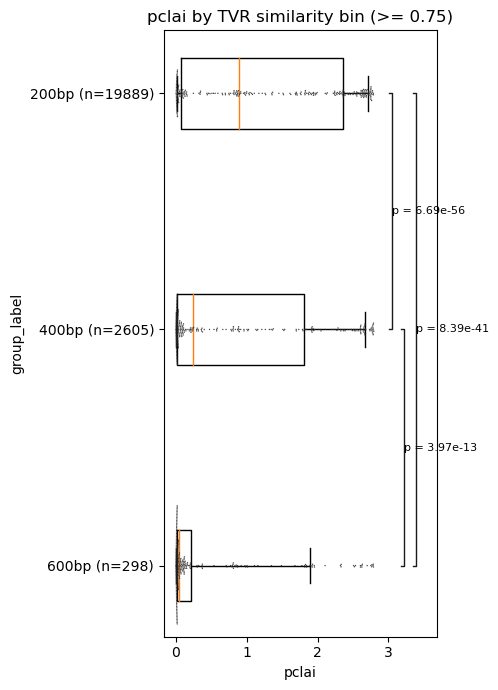

In [60]:
from itertools import combinations

score_cols = ["sim_t200", "sim_t400", "sim_t600"]

to_plot = []
ns = []

for i in range(stacked_sims.shape[1]):
    sim_idx = stacked_sims[:, i] >= 0.75
    vals = pclai_vals[sim_idx]
    vals = vals[~np.isnan(vals)]
    to_plot.append(vals)
    ns.append(len(vals))

k = 3
groups = to_plot[:k]
group_names = score_cols[:k]
ns = ns[:k]

group_labels = [f"{name[-3:]}bp (n={n})" for name, n in zip(group_names, ns)]
order_labels = group_labels[:]  

max_swarm = 250
rng = np.random.default_rng(0)

swarm_rows = []
for i, arr in enumerate(groups):
    if len(arr) == 0:
        continue
    if len(arr) > max_swarm:
        arr = arr[rng.choice(len(arr), size=max_swarm, replace=False)]

    swarm_rows.append(pd.DataFrame({
        "group_label": group_labels[i],
        "value": arr
    }))

df_swarm = pd.concat(swarm_rows, ignore_index=True) if swarm_rows else pd.DataFrame(
    columns=["group_label", "value"]
)



def format_p(p):
    if np.isnan(p):
        return "p = nan"
    if p < 0.001:
        return f"p = {p:.2e}"
    else:
        return f"p = {p:.8f}"

def add_sig_bar_horizontal(ax, y1, y2, x, w, text, fs=9):
    # y1,y2 are numeric positions (0..k-1)
    ax.plot([x, x+w, x+w, x], [y1, y1, y2, y2], lw=1, color="k")
    ax.text(x + w, (y1 + y2) / 2, text, ha="left", va="center", fontsize=fs)

# ---------- plot ----------
fig, ax = plt.subplots(figsize=(5, 7))

positions = np.arange(k)

bp = ax.boxplot(
    groups,
    sym="",
    whis=(10, 90),
    showfliers=False,
    positions=positions,
    vert=False
)

ax.set_xlabel("pclai")
ax.set_title("pclai by TVR similarity bin (>= 0.75)")

ax.set_yticks(positions)
ax.set_yticklabels(group_labels)

if not df_swarm.empty:
    sns.swarmplot(
        data=df_swarm,
        y="group_label",
        x="value",
        order=order_labels,
        ax=ax,
        size=1,
        color="0.2",
        edgecolor="none",
        linewidth=0,
        alpha=0.9,
        orient="h",
    )

pairs = list(combinations(range(k), 2))

valid_maxs = [np.nanmax(g) for g in groups if len(g)]
x_base = np.nanmax(valid_maxs) if valid_maxs else 0.0

valid_mins = [np.nanmin(g) for g in groups if len(g)]
span = (np.nanmax(valid_maxs) - np.nanmin(valid_mins)) if (valid_mins and valid_maxs) else 1.0
x_step = 0.06 * span if span > 0 else 0.1
w = x_step * 0.25

pairs_sorted = sorted(pairs, key=lambda ij: (ij[1] - ij[0], ij[0]))

x = x_base + x_step
for (i, j) in pairs_sorted:
    a, b = groups[i], groups[j]
    if len(a) == 0 or len(b) == 0:
        p = np.nan
    else:
        _, p = mannwhitneyu(a, b, alternative="two-sided")

    add_sig_bar_horizontal(ax, i, j, x, w, format_p(p), fs=8)
    x += x_step

ax.set_xlim(right=x + x_step)
plt.tight_layout()
plt.show()